# 05 — Classical ML Hyperparameter Tuning
## GTZAN Music Genre Classification

This notebook tunes the four classical ML models from Notebook 04:

1. SVM
2. KNN
3. Random Forest
4. XGBoost

### Experimental protocol

- Use the **existing `split` column** from `handcrafted_features.csv`.
- Do **not** create a new split.
- Train on the 700-song training set.
- Select hyperparameters using the 150-song validation set.
- **Do not use the test set anywhere in this notebook.**
- Primary selection metric: **Validation Macro F1**.
- The final test evaluation belongs to the later **Best Classical Model** experiment.

In [13]:
# =========================
# 1. Install dependencies
# =========================
import sys
import subprocess
import importlib.util

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
    "xgboost": "xgboost",
}

missing = [
    pkg for module, pkg in required.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print("Installing:", missing)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + missing
    )

print("Dependencies ready.")

Dependencies ready.


In [14]:
# =========================
# 2. Imports
# =========================
from pathlib import Path
import json
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.model_selection import ParameterGrid
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Locate the handcrafted feature file

In [15]:
# =========================
# 3. Locate input CSV
# =========================
candidate_paths = [
    Path("/content/handcrafted_output/handcrafted_features.csv"),
    Path("/content/handcrafted_features.csv"),
    Path("handcrafted_output/handcrafted_features.csv"),
    Path("data/processed/handcrafted_features.csv"),
    Path("data/handcrafted_features.csv"),
    Path("handcrafted_features.csv"),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is None:
    try:
        from google.colab import files

        print("handcrafted_features.csv was not found.")
        print("Please upload the CSV generated by Notebook 03.")
        uploaded = files.upload()

        if "handcrafted_features.csv" in uploaded:
            csv_path = Path("/content/handcrafted_features.csv")
        elif uploaded:
            first_name = next(iter(uploaded))
            csv_path = Path("/content") / first_name

    except ImportError:
        pass

if csv_path is None or not csv_path.exists():
    raise FileNotFoundError(
        "Could not find handcrafted_features.csv."
    )

print("Using:")
print(csv_path.resolve())

Using:
/content/handcrafted_features.csv


In [16]:
# =========================
# 4. Load and validate data
# =========================
df = pd.read_csv(csv_path)

required_metadata = {"relative_path", "genre", "split"}
missing_metadata = required_metadata - set(df.columns)

if missing_metadata:
    raise ValueError(
        f"Missing required metadata columns: {missing_metadata}"
    )

numeric_features = [
    c for c in df.columns
    if c not in ["relative_path", "genre", "split"]
]

if len(numeric_features) != 137:
    raise ValueError(
        f"Expected 137 handcrafted features, found {len(numeric_features)}."
    )

if df[numeric_features].isnull().any().any():
    raise ValueError("Missing numeric feature values detected.")

if set(df["split"].unique()) != {"train", "validation", "test"}:
    raise ValueError(
        f"Unexpected split labels: {sorted(df['split'].unique())}"
    )

print("Shape:", df.shape)
print("Numeric features:", len(numeric_features))
print("\nSplit counts:")
print(df["split"].value_counts().sort_index())

Shape: (1000, 140)
Numeric features: 137

Split counts:
split
test          150
train         700
validation    150
Name: count, dtype: int64


## 5. Prepare the fixed train/validation/test partitions

The test set is loaded only to verify that it exists and remains untouched.

No test samples are used for tuning.

In [17]:
# =========================
# 5. Existing split only
# =========================
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

X_train = train_df[numeric_features].astype(np.float32)
y_train = train_df["genre"].astype(str)

X_val = val_df[numeric_features].astype(np.float32)
y_val = val_df["genre"].astype(str)

X_test = test_df[numeric_features].astype(np.float32)
y_test = test_df["genre"].astype(str)

assert len(X_train) == 700
assert len(X_val) == 150
assert len(X_test) == 150

# Explicit leakage checks.
assert set(train_df["relative_path"]).isdisjoint(
    val_df["relative_path"]
)
assert set(train_df["relative_path"]).isdisjoint(
    test_df["relative_path"]
)
assert set(val_df["relative_path"]).isdisjoint(
    test_df["relative_path"]
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("\nLeakage checks passed.")

Train: (700, 137)
Validation: (150, 137)
Test: (150, 137)

Leakage checks passed.


## 6. XGBoost label encoding

Scikit-learn models can use the original genre strings.

XGBoost requires integer class labels, so only the XGBoost branch uses:

```text
blues     → 0
classical → 1
country   → 2
...
```

Predictions are converted back to the original genre names before calculating metrics.

In [18]:
# =========================
# 6. Encode labels for XGBoost
# =========================
label_encoder = LabelEncoder()
label_encoder.fit(sorted(df["genre"].astype(str).unique()))

y_train_xgb = label_encoder.transform(y_train)
y_val_xgb = label_encoder.transform(y_val)

print("XGBoost label mapping:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"{idx:2d} -> {label}")

XGBoost label mapping:
 0 -> blues
 1 -> classical
 2 -> country
 3 -> disco
 4 -> hiphop
 5 -> jazz
 6 -> metal
 7 -> pop
 8 -> reggae
 9 -> rock


In [19]:
# =========================
# 7. Evaluation helper
# =========================
def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }


def evaluate_candidate(
    model_name,
    model,
    x_train,
    y_train_original,
    x_val,
    y_val_original
):
    start = time.time()

    if model_name == "XGBoost":
        model.fit(x_train, y_train_xgb)
        pred_encoded = model.predict(x_val).astype(int).ravel()
        pred = label_encoder.inverse_transform(pred_encoded)
    else:
        model.fit(x_train, y_train_original)
        pred = model.predict(x_val)

    metrics = calculate_metrics(y_val_original, pred)
    elapsed = time.time() - start

    return metrics, elapsed

# 8. SVM Hyperparameter Tuning

Search space:

- `C`: 0.1, 1, 10, 100
- `gamma`: scale, 0.01, 0.001

The kernel remains RBF because the baseline already established the RBF formulation for this experiment.

In [20]:
# =========================
# 8. SVM tuning
# =========================
svm_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001],
}

svm_results = []

for params in ParameterGrid(svm_grid):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            C=params["C"],
            gamma=params["gamma"],
            random_state=RANDOM_STATE
        ))
    ])

    metrics, elapsed = evaluate_candidate(
        "SVM",
        model,
        X_train,
        y_train,
        X_val,
        y_val
    )

    svm_results.append({
        "model": "SVM",
        **params,
        **metrics,
        "time_seconds": elapsed
    })

svm_results_df = (
    pd.DataFrame(svm_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("SVM tuning complete.")
display(svm_results_df.style.format({
    "accuracy": "{:.4f}",
    "macro_precision": "{:.4f}",
    "macro_recall": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
    "time_seconds": "{:.2f}",
}))

SVM tuning complete.


,model,C,gamma,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,time_seconds
0,SVM,10.000000,0.001000,0.8000,0.8051,0.8000,0.7974,0.7974,0.15
1,SVM,100.000000,0.001000,0.7867,0.7955,0.7867,0.7833,0.7833,0.13
2,SVM,100.000000,scale,0.7800,0.7863,0.7800,0.7791,0.7791,0.27
3,SVM,10.000000,scale,0.7800,0.7863,0.7800,0.7791,0.7791,0.17
4,SVM,10.000000,0.010000,0.7667,0.7712,0.7667,0.7660,0.7660,0.20
5,SVM,100.000000,0.010000,0.7667,0.7712,0.7667,0.7660,0.7660,0.20
6,SVM,1.000000,scale,0.7533,0.7598,0.7533,0.7525,0.7525,0.18
7,SVM,1.000000,0.010000,0.7533,0.7594,0.7533,0.7523,0.7523,0.18
8,SVM,1.000000,0.001000,0.6533,0.6680,0.6533,0.6504,0.6504,0.15
9,SVM,0.100000,0.010000,0.6133,0.6337,0.6133,0.6153,0.6153,0.23


# 9. KNN Hyperparameter Tuning

Search space:

- `n_neighbors`: 3, 5, 7, 9, 11
- `weights`: uniform, distance

Standardization is applied inside the pipeline.

In [21]:
# =========================
# 9. KNN tuning
# =========================
knn_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
}

knn_results = []

for params in ParameterGrid(knn_grid):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(
            n_neighbors=params["n_neighbors"],
            weights=params["weights"]
        ))
    ])

    metrics, elapsed = evaluate_candidate(
        "KNN",
        model,
        X_train,
        y_train,
        X_val,
        y_val
    )

    knn_results.append({
        "model": "KNN",
        **params,
        **metrics,
        "time_seconds": elapsed
    })

knn_results_df = (
    pd.DataFrame(knn_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("KNN tuning complete.")
display(knn_results_df.style.format({
    "accuracy": "{:.4f}",
    "macro_precision": "{:.4f}",
    "macro_recall": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
    "time_seconds": "{:.2f}",
}))

KNN tuning complete.


,model,n_neighbors,weights,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,time_seconds
0,KNN,7,uniform,0.6733,0.6823,0.6733,0.6673,0.6673,0.05
1,KNN,11,uniform,0.6667,0.6777,0.6667,0.6622,0.6622,0.07
2,KNN,5,uniform,0.6667,0.6708,0.6667,0.6586,0.6586,0.05
3,KNN,5,distance,0.6600,0.6708,0.6600,0.6550,0.6550,0.06
4,KNN,7,distance,0.6600,0.6787,0.6600,0.6539,0.6539,0.08
5,KNN,3,uniform,0.6600,0.6755,0.6600,0.6534,0.6534,0.05
6,KNN,11,distance,0.6533,0.6777,0.6533,0.6491,0.6491,0.06
7,KNN,9,distance,0.6533,0.6773,0.6533,0.6489,0.6489,0.10
8,KNN,3,distance,0.6533,0.6693,0.6533,0.6487,0.6487,0.04
9,KNN,9,uniform,0.6467,0.6579,0.6467,0.6406,0.6406,0.11


# 10. Random Forest Hyperparameter Tuning

Search space:

- `n_estimators`: 200, 500
- `max_depth`: None, 20, 30
- `min_samples_split`: 2, 5
- `max_features`: sqrt

This gives 12 configurations.

In [22]:
# =========================
# 10. Random Forest tuning
# =========================
rf_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt"],
}

rf_results = []

for params in ParameterGrid(rf_grid):
    model = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )

    metrics, elapsed = evaluate_candidate(
        "Random Forest",
        model,
        X_train,
        y_train,
        X_val,
        y_val
    )

    rf_results.append({
        "model": "Random Forest",
        **params,
        **metrics,
        "time_seconds": elapsed
    })

rf_results_df = (
    pd.DataFrame(rf_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("Random Forest tuning complete.")
display(rf_results_df.style.format({
    "accuracy": "{:.4f}",
    "macro_precision": "{:.4f}",
    "macro_recall": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
    "time_seconds": "{:.2f}",
}))

Random Forest tuning complete.


,model,max_depth,max_features,min_samples_split,n_estimators,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,time_seconds
0,Random Forest,nan,sqrt,2,200,0.7867,0.7914,0.7867,0.7875,0.7875,3.43
1,Random Forest,20.000000,sqrt,2,200,0.7867,0.7914,0.7867,0.7875,0.7875,3.40
2,Random Forest,30.000000,sqrt,2,200,0.7867,0.7914,0.7867,0.7875,0.7875,1.75
3,Random Forest,nan,sqrt,2,500,0.7867,0.7894,0.7867,0.7855,0.7855,10.95
4,Random Forest,30.000000,sqrt,2,500,0.7867,0.7894,0.7867,0.7855,0.7855,4.03
5,Random Forest,20.000000,sqrt,2,500,0.7867,0.7874,0.7867,0.7849,0.7849,5.57
6,Random Forest,30.000000,sqrt,5,500,0.7867,0.7859,0.7867,0.7848,0.7848,6.42
7,Random Forest,nan,sqrt,5,500,0.7867,0.7859,0.7867,0.7848,0.7848,10.11
8,Random Forest,20.000000,sqrt,5,500,0.7867,0.7859,0.7867,0.7848,0.7848,5.50
9,Random Forest,nan,sqrt,5,200,0.7733,0.7789,0.7733,0.7730,0.7730,3.73


# 11. XGBoost Hyperparameter Tuning

XGBoost uses integer-encoded labels internally.

Search space:

- `n_estimators`: 200, 400
- `max_depth`: 3, 5, 7
- `learning_rate`: 0.05, 0.1
- `subsample`: 0.9
- `colsample_bytree`: 0.9

This gives 12 configurations.

In [23]:
# =========================
# 11. XGBoost tuning
# =========================
xgb_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.9],
    "colsample_bytree": [0.9],
}

xgb_results = []

for params in ParameterGrid(xgb_grid):
    model = XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        **params
    )

    metrics, elapsed = evaluate_candidate(
        "XGBoost",
        model,
        X_train,
        y_train,
        X_val,
        y_val
    )

    xgb_results.append({
        "model": "XGBoost",
        **params,
        **metrics,
        "time_seconds": elapsed
    })

xgb_results_df = (
    pd.DataFrame(xgb_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("XGBoost tuning complete.")
display(xgb_results_df.style.format({
    "accuracy": "{:.4f}",
    "macro_precision": "{:.4f}",
    "macro_recall": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
    "time_seconds": "{:.2f}",
}))

XGBoost tuning complete.


,model,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,time_seconds
0,XGBoost,0.900000,0.050000,5,400,0.900000,0.7867,0.7907,0.7867,0.7831,0.7831,30.09
1,XGBoost,0.900000,0.100000,5,400,0.900000,0.7867,0.7889,0.7867,0.7829,0.7829,16.92
2,XGBoost,0.900000,0.100000,3,400,0.900000,0.7867,0.7895,0.7867,0.7826,0.7826,14.03
3,XGBoost,0.900000,0.100000,3,200,0.900000,0.7867,0.7910,0.7867,0.7821,0.7821,10.34
4,XGBoost,0.900000,0.100000,5,200,0.900000,0.7800,0.7864,0.7800,0.7775,0.7775,13.68
5,XGBoost,0.900000,0.100000,7,200,0.900000,0.7733,0.7816,0.7733,0.7715,0.7715,15.35
6,XGBoost,0.900000,0.050000,7,200,0.900000,0.7733,0.7775,0.7733,0.7703,0.7703,25.16
7,XGBoost,0.900000,0.100000,7,400,0.900000,0.7733,0.7780,0.7733,0.7695,0.7695,20.05
8,XGBoost,0.900000,0.050000,5,200,0.900000,0.7667,0.7702,0.7667,0.7635,0.7635,22.49
9,XGBoost,0.900000,0.050000,7,400,0.900000,0.7667,0.7700,0.7667,0.7626,0.7626,28.70


# 12. Combine all tuning results

The best configuration for each algorithm is selected using **validation Macro F1**.

In [24]:
# =========================
# 12. Combine tuning results
# =========================
all_tuning_results = pd.concat(
    [
        svm_results_df,
        knn_results_df,
        rf_results_df,
        xgb_results_df,
    ],
    ignore_index=True,
    sort=False
)

all_tuning_results = all_tuning_results.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

print("Top configurations across all four algorithms:")
display(
    all_tuning_results[
        [
            "model",
            "macro_f1",
            "accuracy",
            "macro_precision",
            "macro_recall",
            "weighted_f1"
        ]
    ].head(15).style.format("{:.4f}", subset=[
        "macro_f1",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "weighted_f1"
    ])
)

Top configurations across all four algorithms:


,model,macro_f1,accuracy,macro_precision,macro_recall,weighted_f1
0,SVM,0.7974,0.8000,0.8051,0.8000,0.7974
1,Random Forest,0.7875,0.7867,0.7914,0.7867,0.7875
2,Random Forest,0.7875,0.7867,0.7914,0.7867,0.7875
3,Random Forest,0.7875,0.7867,0.7914,0.7867,0.7875
4,Random Forest,0.7855,0.7867,0.7894,0.7867,0.7855
5,Random Forest,0.7855,0.7867,0.7894,0.7867,0.7855
6,Random Forest,0.7849,0.7867,0.7874,0.7867,0.7849
7,Random Forest,0.7848,0.7867,0.7859,0.7867,0.7848
8,Random Forest,0.7848,0.7867,0.7859,0.7867,0.7848
9,Random Forest,0.7848,0.7867,0.7859,0.7867,0.7848


In [25]:
# =========================
# 13. Best configuration per model
# =========================
best_per_model = (
    all_tuning_results
    .sort_values("macro_f1", ascending=False)
    .groupby("model", as_index=False)
    .first()
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

print("Best tuned configuration for each model:")
display(best_per_model)

Best tuned configuration for each model:


,model,C,gamma,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,time_seconds,n_neighbors,weights,max_depth,max_features,min_samples_split,n_estimators,colsample_bytree,learning_rate,subsample
0,SVM,10.0,0.001,0.800000,0.805114,0.800000,0.797406,0.797406,0.147565,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN
1,Random Forest,NaN,None,0.786667,0.791393,0.786667,0.787539,0.787539,3.401235,NaN,None,20.0,sqrt,2.0,200.0,NaN,NaN,NaN
2,XGBoost,NaN,None,0.786667,0.790734,0.786667,0.783147,0.783147,30.089979,NaN,None,5.0,None,NaN,400.0,0.9,0.05,0.9
3,KNN,NaN,None,0.673333,0.682284,0.673333,0.667250,0.667250,0.047786,7.0,uniform,NaN,None,NaN,NaN,NaN,NaN,NaN


# 14. Select the overall best tuned configuration

The overall winner is selected using **validation Macro F1**.

The test set is still completely untouched.

In [26]:
# =========================
# 14. Overall best tuned model
# =========================
best_tuned_row = all_tuning_results.iloc[0]

best_tuned_model_name = best_tuned_row["model"]
best_tuned_validation_f1 = float(best_tuned_row["macro_f1"])

print("=" * 70)
print("BEST TUNED CLASSICAL MODEL")
print("=" * 70)
print("Model:", best_tuned_model_name)
print(f"Validation Macro F1: {best_tuned_validation_f1:.4f}")
print("\nConfiguration:")

for column in all_tuning_results.columns:
    if column in {
        "model",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "time_seconds"
    }:
        continue

    value = best_tuned_row[column]

    if pd.notna(value):
        print(f"  {column}: {value}")

BEST TUNED CLASSICAL MODEL
Model: SVM
Validation Macro F1: 0.7974

Configuration:
  C: 10.0
  gamma: 0.001


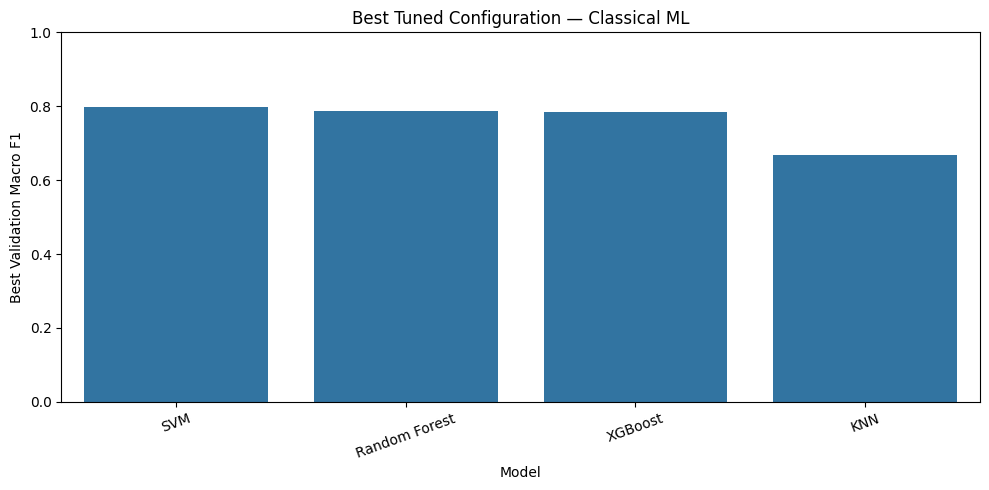

In [27]:
# =========================
# 15. Compare tuned algorithms
# =========================
plt.figure(figsize=(10, 5))

plot_df = best_per_model.copy()

sns.barplot(
    data=plot_df,
    x="model",
    y="macro_f1"
)

plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Best Validation Macro F1")
plt.title("Best Tuned Configuration — Classical ML")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 16. Baseline vs tuned comparison

This section quantifies whether hyperparameter tuning improved the validation performance.

The baseline values can be copied from Notebook 04 if that notebook was already executed.

In [28]:
# =========================
# 16. Baseline vs tuned
# =========================
print("Best tuned validation Macro F1 by model:")
for _, row in best_per_model.iterrows():
    print(f"{row['model']:16s}: {row['macro_f1']:.4f}")

print("\nNote:")
print("Compare these values with Notebook 04 baseline Macro F1 values.")
print("Do not use test performance to claim a tuning improvement.")

Best tuned validation Macro F1 by model:
SVM             : 0.7974
Random Forest   : 0.7875
XGBoost         : 0.7831
KNN             : 0.6673

Note:
Compare these values with Notebook 04 baseline Macro F1 values.
Do not use test performance to claim a tuning improvement.


# 17. Save tuning results

This notebook saves:

- all tested configurations
- best configuration per algorithm
- overall best tuned configuration
- label encoder for XGBoost
- experiment metadata

It does **not** evaluate the test set.

In [29]:
# =========================
# 17. Save tuning results
# =========================
results_dir = Path("results")
tables_dir = results_dir / "tables"
models_dir = Path("models")

tables_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

all_tuning_results.to_csv(
    tables_dir / "classical_ml_hyperparameter_tuning_all.csv",
    index=False
)

best_per_model.to_csv(
    tables_dir / "classical_ml_hyperparameter_tuning_best_per_model.csv",
    index=False
)

best_tuned_row.to_frame().T.to_csv(
    tables_dir / "classical_ml_best_tuned_configuration.csv",
    index=False
)

joblib.dump(
    label_encoder,
    models_dir / "xgboost_label_encoder.joblib"
)

metadata = {
    "project": "Music Genre Classification",
    "dataset": "GTZAN",
    "n_songs": int(len(df)),
    "n_features": int(len(numeric_features)),
    "train_samples": int(len(X_train)),
    "validation_samples": int(len(X_val)),
    "test_samples": int(len(X_test)),
    "selection_metric": "validation_macro_f1",
    "test_used_for_tuning": False,
    "best_tuned_model": str(best_tuned_model_name),
    "best_validation_macro_f1": best_tuned_validation_f1,
    "random_state": RANDOM_STATE,
}

with open(
    results_dir / "classical_ml_tuning_config.json",
    "w"
) as f:
    json.dump(metadata, f, indent=2)

print("Saved tuning outputs:")
print(
    tables_dir /
    "classical_ml_hyperparameter_tuning_all.csv"
)
print(
    tables_dir /
    "classical_ml_hyperparameter_tuning_best_per_model.csv"
)
print(
    tables_dir /
    "classical_ml_best_tuned_configuration.csv"
)
print(
    results_dir /
    "classical_ml_tuning_config.json"
)

Saved tuning outputs:
results/tables/classical_ml_hyperparameter_tuning_all.csv
results/tables/classical_ml_hyperparameter_tuning_best_per_model.csv
results/tables/classical_ml_best_tuned_configuration.csv
results/classical_ml_tuning_config.json


# 18. Final tuning summary

## What this experiment establishes

1. The best hyperparameters for SVM.
2. The best hyperparameters for KNN.
3. The best hyperparameters for Random Forest.
4. The best hyperparameters for XGBoost.
5. The overall best tuned classical ML configuration.

### Next experiment

Do **not** evaluate the test set here.

The next notebook will take the selected configuration, retrain it using **train + validation**, and perform the final held-out test evaluation.

In [30]:
# =========================
# 18. Final summary
# =========================
print("=" * 80)
print("CLASSICAL ML HYPERPARAMETER TUNING — SUMMARY")
print("=" * 80)
print(f"Training samples       : {len(X_train)}")
print(f"Validation samples     : {len(X_val)}")
print(f"Test samples           : {len(X_test)}")
print(f"Features               : {len(numeric_features)}")
print(f"Selection metric       : Validation Macro F1")
print(f"Best tuned model       : {best_tuned_model_name}")
print(f"Best validation F1     : {best_tuned_validation_f1:.4f}")
print("=" * 80)
print("TEST SET WAS NOT USED FOR MODEL SELECTION.")

CLASSICAL ML HYPERPARAMETER TUNING — SUMMARY
Training samples       : 700
Validation samples     : 150
Test samples           : 150
Features               : 137
Selection metric       : Validation Macro F1
Best tuned model       : SVM
Best validation F1     : 0.7974
TEST SET WAS NOT USED FOR MODEL SELECTION.
